In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning/

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/microscopy_self_supervised_learning


Imports & setup

In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from skimage.io import imread
from skimage.transform import resize
import cv2

from sklearn.preprocessing import LabelEncoder, StandardScaler

Paths & metadata

In [4]:
metadata = pd.read_csv("data/processed/metadata_with_moa.csv")
metadata.tail(3)

,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,plate,well,Replicate,compound,concentration,moa
3845,9,3598,Week9_090907_G11_s2_w10B010F39-3B4B-4DCB-8E34-...,Week9_39301,Week9_090907_G11_s2_w2720AC778-3F85-4293-8D75-...,Week9_39301,Week9_090907_G11_s2_w49B290958-BCF2-4DDD-B0E9-...,Week9_39301,Week9_39301,G11,3,DMSO,0.0,DMSO
3846,9,3599,Week9_090907_G11_s3_w10394282C-6D3D-4E0E-9FA3-...,Week9_39301,Week9_090907_G11_s3_w24C59DB62-E99B-4284-BAD2-...,Week9_39301,Week9_090907_G11_s3_w471FE25C8-2477-456F-9D74-...,Week9_39301,Week9_39301,G11,3,DMSO,0.0,DMSO
3847,9,3600,Week9_090907_G11_s4_w1C447A151-1F85-4E19-9C96-...,Week9_39301,Week9_090907_G11_s4_w22E574F48-321D-4470-ACC4-...,Week9_39301,Week9_090907_G11_s4_w4200C5003-7F75-47DF-928C-...,Week9_39301,Week9_39301,G11,3,DMSO,0.0,DMSO


In [155]:
DATA_DIR = "data/raw"
RESULTS_DIR = "results/figures"
PROCESSED_DIR = "data/processed"

In [6]:
metadata['Image_FileName_DAPI'][0]

'Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-9CC39666813B.tif'

In [7]:
X = np.load("data/splits/X_images.npy")
y = np.load("data/splits/y_labels.npy")

print(X.shape)
print(y.shape)

(3845, 3, 128, 128)
(3845, 3)


Image loader function

In [13]:
from torch.utils.data import Dataset
import torch

class MicroscopyDataset(Dataset):

    def __init__(self, X):
        self.X = X

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        img = torch.tensor(self.X[idx], dtype=torch.float32)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        return img

In [15]:
from torch.utils.data import DataLoader

dataset = MicroscopyDataset(X)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [16]:
imgs = next(iter(dataloader))

print(imgs.shape)
print(imgs.min(), imgs.max())

torch.Size([64, 3, 128, 128])
tensor(0.) tensor(1.)


Masked Autoencoder Model (Transformer)

In [99]:
import torch
import torch.nn as nn

class MAE(nn.Module):

    def __init__(
        self,
        img_size=128,
        patch_size=16,
        embed_dim=256,
        depth=4,
        num_heads=8,
        mask_ratio=0.50
    ):
        super().__init__()

        self.patch_size = patch_size
        self.mask_ratio = mask_ratio

        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = 3 * patch_size * patch_size

        self.patch_embed = nn.Linear(patch_dim, embed_dim)

        self.pos_embed = nn.Parameter(
            torch.randn(1, self.num_patches, embed_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

        self.decoder = nn.Linear(embed_dim, patch_dim)

    # ---------------------------
    # PATCHIFY
    # ---------------------------
    def patchify(self, imgs):

        B, C, H, W = imgs.shape
        p = self.patch_size

        patches = imgs.unfold(2, p, p).unfold(3, p, p)

        patches = patches.contiguous().view(B, C, -1, p, p)

        patches = patches.permute(0, 2, 1, 3, 4)

        patches = patches.reshape(B, self.num_patches, -1)

        return patches

    # ---------------------------
    # MASKING
    # ---------------------------
    def random_mask(self, x):

        B, N, D = x.shape
        len_keep = int(N * (1 - self.mask_ratio))

        noise = torch.rand(B, N, device=x.device)

        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        ids_keep = ids_shuffle[:, :len_keep]

        x_masked = torch.gather(
            x, 1, ids_keep.unsqueeze(-1).repeat(1,1,D)
        )

        mask = torch.ones(B, N, device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, 1, ids_restore)

        return x_masked, mask

    # ---------------------------
    # FORWARD (THIS WAS MISSING)
    # ---------------------------
    def forward(self, imgs):

        patches = self.patchify(imgs)

        tokens = self.patch_embed(patches) + self.pos_embed

        visible_tokens, mask = self.random_mask(tokens)

        latent = self.encoder(visible_tokens)

        recon = self.decoder(latent)

        return recon, patches, mask, latent

In [100]:
def mae_loss(recon, patches, mask):

    target = patches[:, :recon.shape[1], :]

    loss = (recon - target) ** 2

    loss = loss.mean(dim=-1)   # per patch

    loss = (loss * mask[:, :recon.shape[1]]).sum() / mask.sum()

    return loss

Optimizer (MAE uses AdamW + weight decay)

In [101]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [102]:
model = MAE().to(device)

In [103]:
import torch.optim as optim

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

Cosine Learning Rate Scheduler

In [104]:
num_epochs = 75

In [105]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)

Training Loop

In [106]:
train_losses = []
warmup_epochs = 10
base_lr = 3e-4

for epoch in range(num_epochs):

    # ---------------------------
    # ✅ LR WARMUP (FIXED INDENT)
    # ---------------------------
    if epoch < warmup_epochs:
        lr = base_lr * (epoch + 1) / warmup_epochs

        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

    # ---------------------------
    # TRAINING
    # ---------------------------
    model.train()
    running_loss = 0.0

    loop = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for imgs in loop:   # ✅ FIX: no labels

        imgs = imgs.float().to(device)

        recon, patches, mask, latent = model(imgs)

        # ---------------------------
        # ✅ CORRECT MAE LOSS
        # ---------------------------
        target = patches[:, :recon.shape[1], :]

        loss = (recon - target) ** 2
        loss = loss.mean(dim=-1)   # per patch

        loss = (loss * mask[:, :recon.shape[1]]).sum() / mask.sum()

        # ---------------------------
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        loop.set_postfix(loss=loss.item())

    # ---------------------------
    # ✅ SCHEDULER AFTER WARMUP
    # ---------------------------
    if epoch >= warmup_epochs:
        scheduler.step()

    epoch_loss = running_loss / len(dataloader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1} Loss: {epoch_loss:.4f}")

Epoch 1/75: 100%|██████████| 61/61 [02:16<00:00,  2.24s/it, loss=0.0228]


Epoch 1 Loss: 0.0704


Epoch 2/75: 100%|██████████| 61/61 [02:10<00:00,  2.14s/it, loss=0.0135]


Epoch 2 Loss: 0.0203


Epoch 3/75: 100%|██████████| 61/61 [02:13<00:00,  2.19s/it, loss=0.0271]


...

Epoch 73 Loss: 0.0101


Epoch 74/75: 100%|██████████| 61/61 [02:11<00:00,  2.16s/it, loss=0.00793]


Epoch 74 Loss: 0.0101


Epoch 75/75: 100%|██████████| 61/61 [02:13<00:00,  2.20s/it, loss=0.0103]

Epoch 75 Loss: 0.0101


In [107]:
print("Number of patches:", model.num_patches) #expected 64

Number of patches: 64


Mask ratio

In [108]:
print("Mask ratio:", mask.mean().item()) #expected 0.75

Mask ratio: 0.5


Latent shape

In [109]:
print("Latent shape:", latent.shape) #expected [batch, 16, 256]

Latent shape: torch.Size([5, 32, 256])


Meaning

64 patches
75% masked
16 visible

Extract Embeddings

In [110]:
model.eval()

embeddings = []

with torch.no_grad():

    for imgs in dataloader:

        imgs = imgs.to(device)

        _, _, _, latent = model(imgs)

        emb = latent.mean(dim=1)

        embeddings.append(emb.cpu())

Downstream tasks

In [151]:
moa = y[:,0]
compound = y[:, 1]
concentration = y[:, 2]

In [112]:
replicate_groups = np.array([
    f"{c}_{d}" for c, d in zip(compound, concentration)
])

In [113]:
X_embeddings = torch.cat(embeddings, dim=0).numpy()

Reconstruction of an image

In [114]:
model.eval()

imgs = next(iter(dataloader))
imgs = imgs.to(device)

In [115]:
with torch.no_grad():
    recon, patches, mask, _ = model(imgs)

In [116]:
print("imgs:", imgs.shape)        # (B, 3, 128, 128)
print("patches:", patches.shape)  # (B, 64, 768)
print("recon:", recon.shape)      # (B, num_masked, 768)
print("mask:", mask.shape)        # (B, 64)

imgs: torch.Size([64, 3, 128, 128])
patches: torch.Size([64, 64, 768])
recon: torch.Size([64, 32, 768])
mask: torch.Size([64, 64])


In [72]:
def reconstruct_full_image(patches, recon, mask):
    full_recon = patches.clone()

    for i in range(patches.shape[0]):

        masked_idx = torch.where(mask[i] == 1)[0]

        # 🔥 Only take as many recon patches as available
        num_recon = recon[i].shape[0]

        full_recon[i, masked_idx[:num_recon]] = recon[i]

    return full_recon

In [69]:
#Unpatchify
def unpatchify(x, patch_size=16, img_size=128):
    B, N, D = x.shape
    h = w = img_size // patch_size

    x = x.reshape(B, h, w, patch_size, patch_size, 3)
    x = x.permute(0, 5, 1, 3, 2, 4)
    imgs = x.reshape(B, 3, img_size, img_size)

    return imgs

In [117]:
with torch.no_grad():
    recon, patches, mask, _ = model(imgs)

full_recon = reconstruct_full_image(patches, recon, mask)

recon_imgs = unpatchify(full_recon)

In [118]:
masked_patches = patches.clone()

for i in range(patches.shape[0]):
    masked_idx = mask[i].bool()
    masked_patches[i, masked_idx] = 0

masked_imgs = unpatchify(masked_patches)

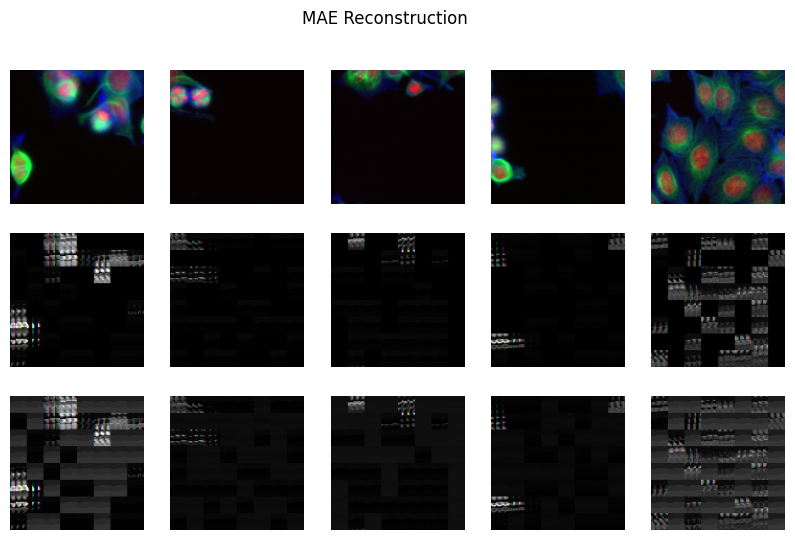

In [119]:
import matplotlib.pyplot as plt

def show_image(img):
    img = img.permute(1,2,0).cpu().numpy()
    plt.imshow(img)
    plt.axis("off")

n = 5

plt.figure(figsize=(10,6))

for i in range(n):

    # original
    plt.subplot(3, n, i+1)
    show_image(imgs[i])

    # masked
    plt.subplot(3, n, i+1+n)
    show_image(masked_imgs[i])

    # reconstructed
    plt.subplot(3, n, i+1+2*n)
    show_image(recon_imgs[i])

plt.suptitle("MAE Reconstruction")
plt.show()

In [120]:
print("recon_imgs:", recon_imgs.shape)
print("masked_imgs:", masked_imgs.shape)

recon_imgs: torch.Size([64, 3, 128, 128])
masked_imgs: torch.Size([64, 3, 128, 128])


In [121]:
diff = torch.abs(imgs - recon_imgs)
#diff

MOA Prediction

In [152]:
le = LabelEncoder()
y_enc = le.fit_transform(moa)

In [134]:
from sklearn.preprocessing import normalize
X_embeddings = normalize(X_embeddings)

In [135]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

k_values = range(1, 31)

results = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(knn, X_embeddings, y_enc, cv=5)

    mean_score = scores.mean()

    results.append(mean_score)

    print(f"k = {k}, accuracy = {mean_score:.4f}")

k = 1, accuracy = 0.2707
k = 2, accuracy = 0.2606
k = 3, accuracy = 0.2830
k = 4, accuracy = 0.3095
k = 5, accuracy = 0.3246
k = 6, accuracy = 0.3399
k = 7, accuracy = 0.3420
k = 8, accuracy = 0.3397
k = 9, accuracy = 0.3417
k = 10, accuracy = 0.3467
k = 11, accuracy = 0.3527
k = 12, accuracy = 0.3584
k = 13, accuracy = 0.3631
k = 14, accuracy = 0.3610
k = 15, accuracy = 0.3620
k = 16, accuracy = 0.3625
k = 17, accuracy = 0.3678
k = 18, accuracy = 0.3670
k = 19, accuracy = 0.3631
k = 20, accuracy = 0.3678
k = 21, accuracy = 0.3683
k = 22, accuracy = 0.3691
k = 23, accuracy = 0.3706
k = 24, accuracy = 0.3680
k = 25, accuracy = 0.3683
k = 26, accuracy = 0.3701
k = 27, accuracy = 0.3701
k = 28, accuracy = 0.3706
k = 29, accuracy = 0.3691
k = 30, accuracy = 0.3688


In [136]:
best_k = k_values[np.argmax(results)]
best_score = max(results)

print("Best k:", best_k)
print("Best accuracy:", best_score)

Best k: 28
Best accuracy: 0.37061118335500653


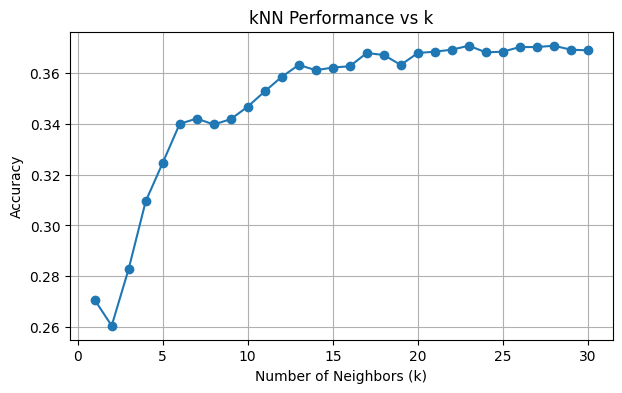

In [137]:
plt.figure(figsize=(7,4))

plt.plot(k_values, results, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("kNN Performance vs k")

plt.grid(True)

plt.show()

LOCO

In [138]:
compound_ids = y[:,1]
compound_enc = LabelEncoder().fit_transform(compound)

In [139]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

logo = LeaveOneGroupOut()

k_values = range(1, 31)   # test k from 1 to 30
k_scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine")

    scores = []

    for train_idx, test_idx in logo.split(X_embeddings, y_enc, groups=compound_ids):

        X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
        y_train, y_test = y_enc[train_idx], y_enc[test_idx]

        knn.fit(X_train, y_train)

        acc = knn.score(X_test, y_test)

        scores.append(acc)

    mean_score = np.mean(scores)
    k_scores.append(mean_score)

    print(f"k = {k}, LOCO accuracy = {mean_score:.4f}")

k = 1, LOCO accuracy = 0.0467
k = 2, LOCO accuracy = 0.0365
k = 3, LOCO accuracy = 0.0302
k = 4, LOCO accuracy = 0.0235
k = 5, LOCO accuracy = 0.0257
k = 6, LOCO accuracy = 0.0314
k = 7, LOCO accuracy = 0.0232
k = 8, LOCO accuracy = 0.0261
k = 9, LOCO accuracy = 0.0256
k = 10, LOCO accuracy = 0.0278
k = 11, LOCO accuracy = 0.0264
k = 12, LOCO accuracy = 0.0313
k = 13, LOCO accuracy = 0.0285
k = 14, LOCO accuracy = 0.0299
k = 15, LOCO accuracy = 0.0292
k = 16, LOCO accuracy = 0.0285
k = 17, LOCO accuracy = 0.0278
k = 18, LOCO accuracy = 0.0264
k = 19, LOCO accuracy = 0.0306
k = 20, LOCO accuracy = 0.0271
k = 21, LOCO accuracy = 0.0285
k = 22, LOCO accuracy = 0.0264
k = 23, LOCO accuracy = 0.0264
k = 24, LOCO accuracy = 0.0278
k = 25, LOCO accuracy = 0.0285
k = 26, LOCO accuracy = 0.0278
k = 27, LOCO accuracy = 0.0292
k = 28, LOCO accuracy = 0.0285
k = 29, LOCO accuracy = 0.0306
k = 30, LOCO accuracy = 0.0306


In [140]:
best_k = k_values[np.argmax(k_scores)]
best_score = max(k_scores)

print("Best k:", best_k)
print("Best LOCO accuracy:", best_score)

Best k: 1
Best LOCO accuracy: 0.04673599887014521


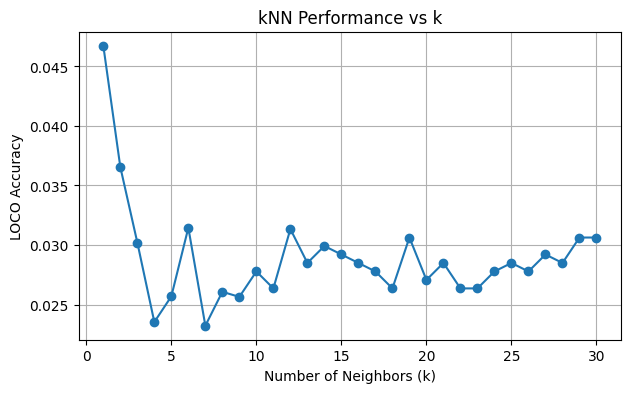

In [141]:
plt.figure(figsize=(7,4))

plt.plot(k_values, k_scores, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("LOCO Accuracy")
plt.title("kNN Performance vs k")

plt.grid(True)

plt.show()

Saving Embeddings

In [156]:
mae_df = pd.DataFrame(X_embeddings, columns=[f"PC{i}" for i in range(1, X_embeddings.shape[1] + 1)])
mae_df["moa"] = moa
mae_df["compound"] = compound
mae_df["concentration"] = concentration

mae_df.to_csv(os.path.join(PROCESSED_DIR, "mae_embeddings.csv"), index=False)

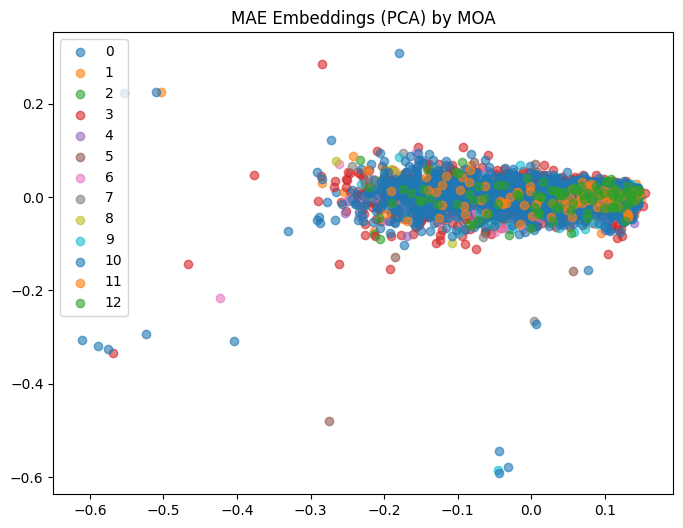

In [142]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(X_embeddings)

plt.figure(figsize=(8,6))

for moa in np.unique(y_enc):
    idx = y_enc == moa
    plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], label=str(moa), alpha=0.6)

plt.legend()
plt.title("MAE Embeddings (PCA) by MOA")
plt.show()

UMAP Visualization

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


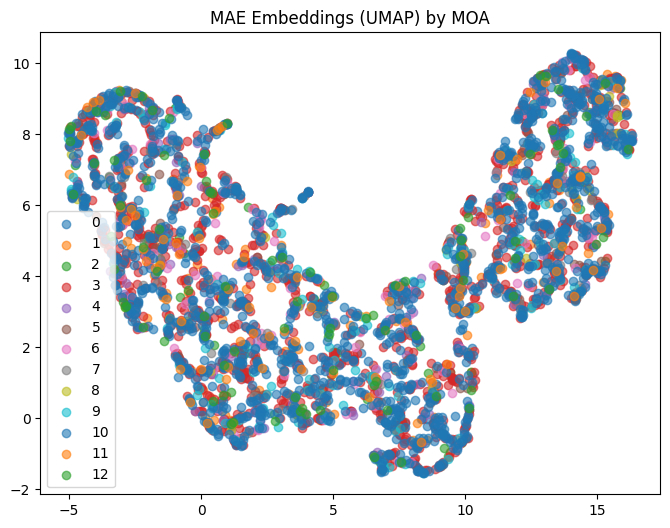

In [143]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
emb_2d = reducer.fit_transform(X_embeddings)

plt.figure(figsize=(8,6))

for moa in np.unique(y_enc):
    idx = y_enc == moa
    plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], label=str(moa), alpha=0.6)

plt.legend()
plt.title("MAE Embeddings (UMAP) by MOA")
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


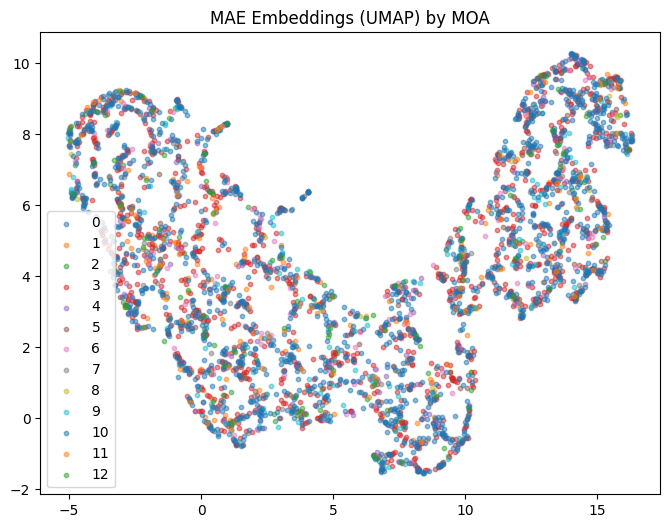

In [144]:
import umap
import matplotlib.pyplot as plt
import numpy as np

reducer = umap.UMAP(n_components=2, random_state=42)
emb_2d = reducer.fit_transform(X_embeddings)

plt.figure(figsize=(8,6))

for moa in np.unique(y_enc):
    idx = y_enc == moa
    plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], label=str(moa), alpha=0.5, s=10)

plt.legend()
plt.title("MAE Embeddings (UMAP) by MOA")
plt.show()

Percent Replicating

In [89]:
from sklearn.metrics.pairwise import cosine_similarity
def percent_replicating(embeddings, replicate_groups):

    sim = cosine_similarity(embeddings)

    replicate_scores = []
    null_scores = []

    n = len(replicate_groups)

    for i in range(n):
        for j in range(i+1, n):

            if replicate_groups[i] == replicate_groups[j]:
                replicate_scores.append(sim[i, j])
            else:
                null_scores.append(sim[i, j])

    threshold = np.percentile(null_scores, 95)

    replicating = np.sum(np.array(replicate_scores) > threshold)

    percent = replicating / len(replicate_scores)

    return percent

In [145]:
mae_rep = percent_replicating(X_embeddings, replicate_groups)


print("PCA percent replicating:", mae_rep)


PCA percent replicating: 0.05009485854198613


Further Visualizations and Evaluations

In [146]:
def create_mask_overlay(imgs, mask, patch_size=16, img_size=128):
    B, _, _, _ = imgs.shape
    h = w = img_size // patch_size

    mask = mask.reshape(B, h, w)

    overlay_imgs = imgs.clone()

    for i in range(B):
        for y in range(h):
            for x in range(w):
                if mask[i, y, x] == 1:
                    y0, y1 = y*patch_size, (y+1)*patch_size
                    x0, x1 = x*patch_size, (x+1)*patch_size

                    # tint masked region red (overlay effect)
                    overlay_imgs[i, :, y0:y1, x0:x1] *= 0.3
                    overlay_imgs[i, 0, y0:y1, x0:x1] += 0.5  # add red

    return overlay_imgs

In [147]:
diff = torch.abs(imgs - recon_imgs)

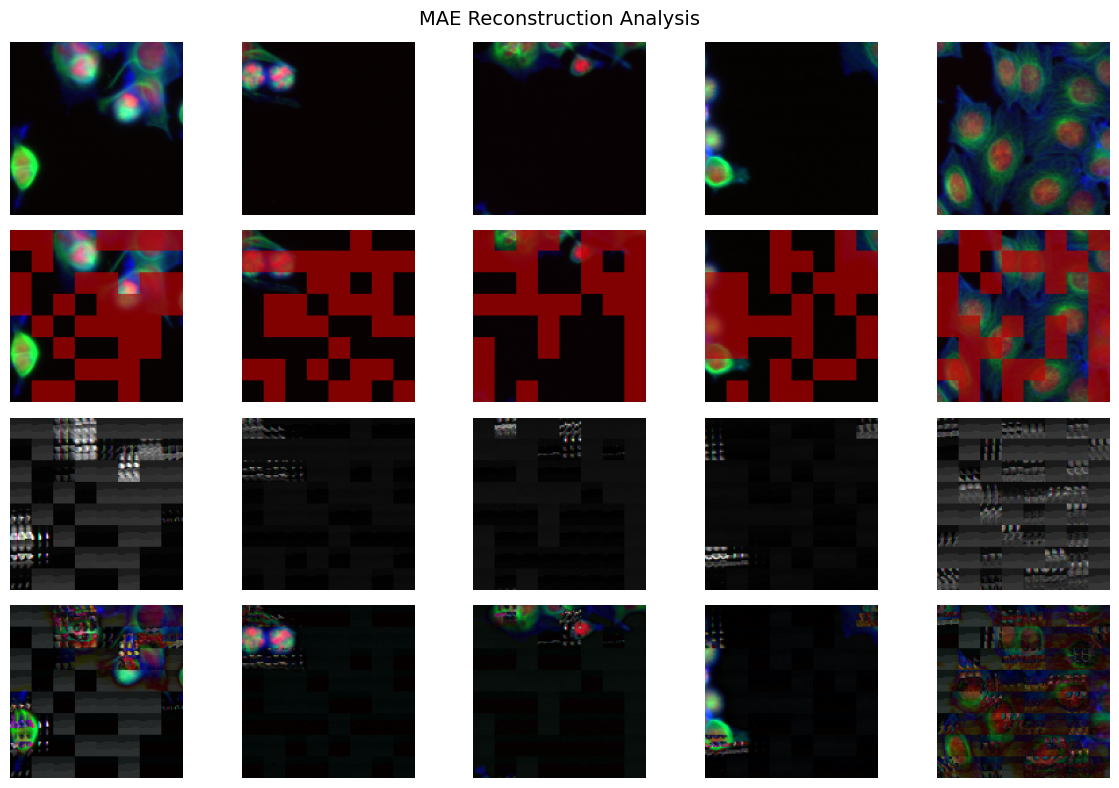

In [148]:
def show(img):
    img = img.permute(1,2,0).cpu().numpy()
    img = img.clip(0,1)
    plt.imshow(img)
    plt.axis("off")

overlay_imgs = create_mask_overlay(imgs, mask)

n = 5
plt.figure(figsize=(12, 8))

for i in range(n):

    # Original
    plt.subplot(4, n, i+1)
    show(imgs[i])
    if i == 0: plt.ylabel("Original")

    # Mask overlay
    plt.subplot(4, n, i+1+n)
    show(overlay_imgs[i])
    if i == 0: plt.ylabel("Masked")

    # Reconstruction
    plt.subplot(4, n, i+1+2*n)
    show(recon_imgs[i])
    if i == 0: plt.ylabel("Reconstruction")

    # Error map
    plt.subplot(4, n, i+1+3*n)
    show(diff[i])
    if i == 0: plt.ylabel("Error")

plt.suptitle("MAE Reconstruction Analysis", fontsize=14)
plt.tight_layout()
plt.show()

mAP

In [94]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def compute_map(embeddings, labels, top_k=10):

    sims = cosine_similarity(embeddings)
    np.fill_diagonal(sims, -1)  # ignore self

    APs = []

    for i in range(len(embeddings)):

        # get top-k neighbors
        idx = np.argsort(sims[i])[::-1][:top_k]

        # relevant = same MOA
        relevant = (labels[idx] == labels[i]).astype(int)

        # compute precision at k
        precisions = []
        correct = 0

        for j, rel in enumerate(relevant):
            if rel:
                correct += 1
                precisions.append(correct / (j+1))

        if len(precisions) > 0:
            APs.append(np.mean(precisions))

    return np.mean(APs)

In [153]:
le = LabelEncoder()
y_enc = le.fit_transform(moa)

In [154]:
map_score = compute_map(X_embeddings, y_enc, top_k=10)
print("mAP@10:", map_score)

mAP@10: 0.4826442835669716


The learned representations achieved an mAP@10 of 0.48,
indicating moderate clustering of compounds by mechanism of action.
However, significant overlap between classes suggests that
the model captures general morphology rather than strongly
discriminative biological features.